In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.applications.xception import Xception
from keras.models import load_model
from pickle import load
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.layers import add
from tensorflow.keras.models import Model
from keras.optimizers import Adam
from keras.utils import to_categorical, get_file
from keras.layers import add
from keras.layers import BatchNormalization
from keras.callbacks import ReduceLROnPlateau, EarlyStopping








2026-03-31 16:34:33.201978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774974873.577921      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774974873.684441      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774974874.670999      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774974874.671037      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774974874.671040      55 computation_placer.cc:177] computation placer alr

In [2]:
import os 
print(os.listdir("/kaggle/input/datasets/halowalker/bas1234"))



['bas_aur_nhi']


In [3]:
# import zipfile

# zip_path = "/kaggle/input/datasets/halowalker/cnlstt/models2 (1)"
# extract_path = "/kaggle/working/models"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Models extracted!")

In [5]:
def extract_features(filename, model):
        try:
            image = Image.open(filename)
            
        except:
            print("ERROR: Couldn't open image! Make sure the image path and extension is correct")
        image = image.resize((299,299))
        image = np.array(image)
        # for images that has 4 channels, we convert them into 3 channels
        if image.shape[2] == 4: 
            image = image[..., :3]
        image = np.expand_dims(image, axis=0)
        image = image/127.5
        image = image - 1.0
        feature = model.predict(image)
        return feature

In [6]:
def word_for_id(integer, tokenizer):
 for word, index in tokenizer.word_index.items():
     if index == integer:
         return word
 return None

In [7]:
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        pred = model.predict([photo,sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text


In [8]:
from keras.utils import plot_model

def define_model(vocab_size, max_length):

    # features from the CNN model squeezed from 2048 to 256 nodes
    inputs1 = Input(shape=(2048,), name='input_1')
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    # LSTM sequence model
    inputs2 = Input(shape=(max_length,), name='input_2')
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    # Merging both models
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    # tie it together [image, seq] [word]
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')

    # summarize model
    print(model.summary())
    plot_model(model, to_file='model.png', show_shapes=True)

    return model

# def define_model(vocab_size, max_length):

#     # Image feature branch
#     inputs1 = Input(shape=(2048,), name='input_1')
#     fe1 = Dropout(0.5)(inputs1)
#     fe2 = Dense(256, activation='relu')(fe1)
#     fe3 = BatchNormalization()(fe2)

#     # Language model branch
#     inputs2 = Input(shape=(max_length,), name='input_2')
#     se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
#     se2 = Dropout(0.5)(se1)
#     se3 = LSTM(256, return_sequences=True)(se2)
#     se4 = LSTM(256)(se3)
#     se5 = BatchNormalization()(se4)

#     # Decoder
#     decoder1 = add([fe3, se5])
#     decoder2 = Dense(256, activation='relu')(decoder1)
#     decoder3 = Dropout(0.3)(decoder2)       # light dropout before output
#     outputs = Dense(vocab_size, activation='softmax')(decoder3)

#     model = Model(inputs=[inputs1, inputs2], outputs=outputs)

#     opt = Adam(learning_rate=0.0009)
#     model.compile(loss='categorical_crossentropy', optimizer=opt)

#     print(model.summary())
#     return model
# def define_model(vocab_size, max_length):

#     # Image feature branch
#     inputs1 = Input(shape=(2048,), name='input_1')
#     fe1 = Dropout(0.5)(inputs1)
#     fe2 = Dense(256, activation='relu')(fe1)
#     fe3 = BatchNormalization()(fe2)
#     fe3 = Dense(256,activation='relu')(fe3)

#     # Language model branch
#     inputs2 = Input(shape=(max_length,), name='input_2')
#     se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
#     se2 = Dropout(0.5)(se1)
#     se3 = LSTM(256, return_sequences=True)(se2)
#     se4 = LSTM(256)(se3)
#     se5 = BatchNormalization()(se4)

#     # Decoder
#     decoder1 = add([fe3, se5])
#     decoder2 = Dense(256, activation='relu')(decoder1)
#     decoder3 = Dropout(0.3)(decoder2)       # light dropout before output
#     outputs = Dense(vocab_size, activation='softmax')(decoder3)

#     model = Model(inputs=[inputs1, inputs2], outputs=outputs)

#     opt = Adam(learning_rate=0.001)
#     model.compile(loss='categorical_crossentropy', optimizer=opt)

#     print(model.summary())
#     return model



In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 34

def generate_caption(model, tokenizer, photo):
    in_text = "startseq"

    for _ in range(max_length):

        seq = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        yhat = model.predict([photo, seq], verbose=0)
        yhat = np.argmax(yhat)

        word = None
        for w, i in tokenizer.word_index.items():
            if i == yhat:
                word = w
                break

        if word is None:
            break

        in_text += " " + word

        if word == "endseq":
            break

    return in_text

In [10]:
tokenizer = load(open(
    "/kaggle/input/datasets/halowalker/bas123/bas/tokenizer5.p",
    "rb"
))

In [11]:
max_length = 34
vocab_size = len(tokenizer.word_index) + 1

In [12]:
model = define_model(vocab_size, max_length)

model.load_weights(
    "/kaggle/input/datasets/halowalker/bas1234/bas_aur_nhi/model_300.h5"
)

I0000 00:00:1774974940.907045      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774974940.913182      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  1,939,712 │ input_2[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_2[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7577)      │  1,947,289 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,002,649 (19.08 MB)

 Trainable params: 5,002,649 (19.08 MB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
xception_model = Xception(include_top=False, pooling="avg")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
img_path = "/kaggle/input/datasets/halowalker/dataset1/Flicker8k_Dataset/1003163366_44323f5815.jpg"

In [19]:
photo = extract_features(img_path, xception_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [20]:
description = generate_desc(model, tokenizer, photo, max_length)

print(description)

start man laying on bench holding leash of dog sitting on ground end


(np.float64(-0.5), np.float64(499.5), np.float64(409.5), np.float64(-0.5))

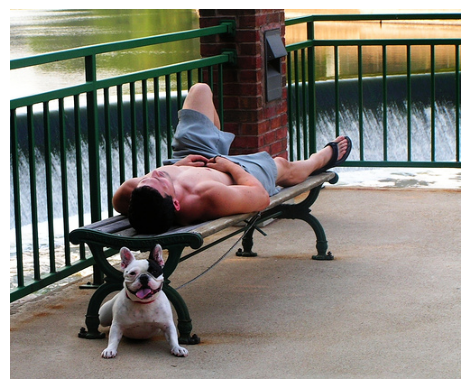

In [21]:
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')